# Projektaufgabe: SBL: bidirektionale Planung mit Lazy Collision Checking

**Vorlesung:** Innovative Konzepte zur Programmierung von Industrierobotern  
**Dozent:** Prof. Dr.-Ing. Björn Hein  
**Gruppe:** <br>
    Christian Mentenich (ugqua) <br>
    Gabrielle Mentenich (udwse) <br>
    Michael Poncelet (urphy) <br>
**Aufgabe:** SBL: bidirektionale Planung mit Lazy Collision Checking  
**Abgabedatum:** 30.07.2026  
**Vortragsdatum:** 31.07.2026

## 1. Abstract

Fassen Sie kurz Problem, Ansatz, wichtigste Ergebnisse und offene Punkte zusammen.

## 2. Objective

Beschreiben Sie die konkrete Aufgabenstellung, eigene Teilziele und experimentelle Fragestellungen.

Michael

Christian

#### Single-query planner
A single query planner uses single or bidirectional search trees that grow through the free space until a 
path from start to goal is found. They work great for dynamic or unknown environments, as they can adapt to 
changes in the environment without requiring a complete map of the space (like multi-query algorithms). In comparison to multi-query algorithms, they are slower per query since they build and search the paths simoultaneously.

#### Goal of this project
The goal is to implement, evaluate, and document an SBL-inspired robot motion planner (Single-query, Bidirectional, Lazy Collision Checking). Unlike multi-query approaches (such as PRM), this planner specifically optimizes for a single start-to-goal problem.

#### Core concepts of the planner
1. Bidirectional Tree Growth: Two trees grow simultaneously, one from the start configuration ($T_{start}$) and one from the goal configuration ($T_{goal}$).
2. Lazy Evaluation: Collision checking of edges is delayed as long as possible. It is only executed once a potential connection (candidate path) between both trees has been found.
3. Adaptive Local Collision Checking: An adaptive midpoint check is used to validate edges. This iteratively checks the midpoint of a segment until the segment length is smaller than $\epsilon$ (epsilon). The test aborts immediately upon detecting the first collision (Early Exit).

## 3. Initial Code and Used Modules

Dokumentieren Sie verwendete Module, erweiterte Klassen/Funktionen, neue Module und den Startpunkt der eigenen Lösung.

In [1]:
import sys
from pathlib import Path
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.collections import LineCollection

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

PosixPath('/home/mp/Documents/KIT/ikp-sbl')

## 4. Concept und Algorithm

Beschreiben Sie den Algorithmus fachlich. Nutzen Sie Skizzen, Pseudocode, Tabellen oder kurze Formeln, wenn sie helfen.

## 5. Implementation

Erläutern Sie die wichtigsten Implementierungsentscheidungen. Umfangreicher Code soll in Modulen liegen und hier importiert werden.

In [2]:
# Eigene Module importieren
# from modules.search_tree import BidirectionalSBL
from modules.adaptive_lazy_tree import BidirectionalSBL
from lecture_examples.IPEnvironment import CollisionChecker

In [ ]:
scene = {"wall": Polygon([(5, 5), (5, 15), (15, 15), (15, 5)])}
#scene = {"wall": Polygon([(2, 2), (2, 3), (3, 3), (3, 2)])}
checker = CollisionChecker(scene)
planner = BidirectionalSBL(checker)

#T_start, T_goal, path = planner.grow_trees([1.0, 1.0], [20.0, 20.0], {"max_nodes": 500, "rho": 3.,"eta": 1.})
T_start, T_goal, path = planner.plan_path([1.0, 1.0], [20.0, 20.0], {"max_nodes": 1000, "eta":2., "kappa_max": 8, "epsilon": 0.05, "iterations": 20})
print(len(T_start.nodes()), len(T_goal.nodes()), path)

TypeError: 'dict' object cannot be interpreted as an integer

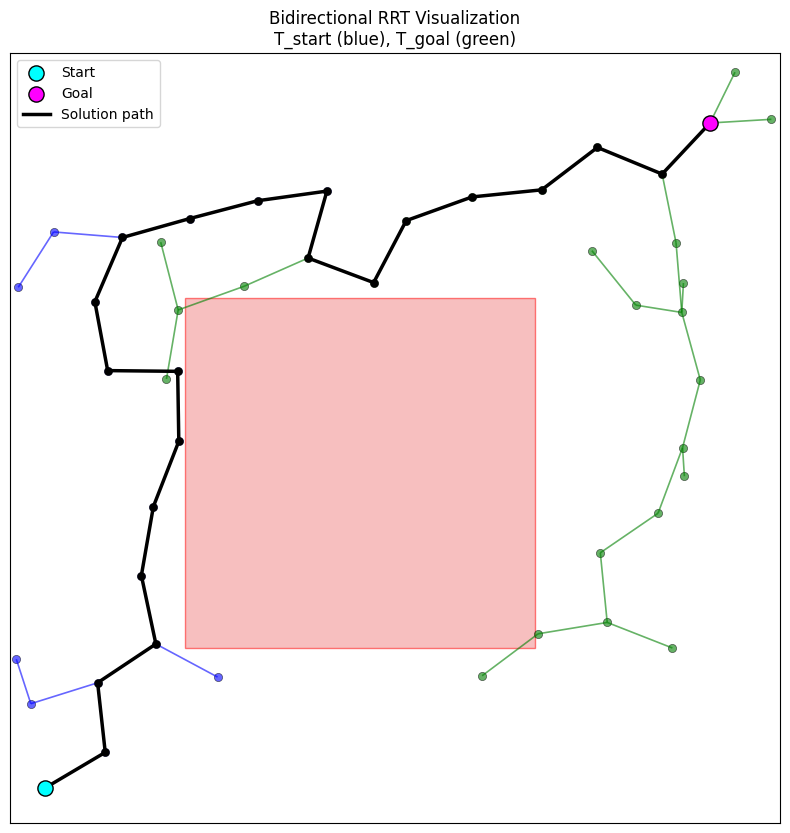

In [ ]:
def draw_obstacles(ax, scene):
    for obstacle in scene.values():
        x, y = obstacle.exterior.xy
        ax.fill(x, y, facecolor="lightcoral", edgecolor="red", alpha=0.5)


def plot_tree(ax, tree, color, node_size=20, alpha=0.6):
    positions = nx.get_node_attributes(tree, "pos")
    if not positions:
        return
    edges = list(tree.edges())
    if edges:
        lines = [[positions[u], positions[v]] for u, v in edges]
        collection = LineCollection(lines, colors=color, linewidths=1.2, alpha=alpha)
        ax.add_collection(collection)
    xs = [pos[0] for pos in positions.values()]
    ys = [pos[1] for pos in positions.values()]
    ax.scatter(xs, ys, c=color, s=node_size, alpha=alpha, edgecolors="black", linewidths=0.5)


def plot_path(ax, path, color="black"):
    if not path:
        return
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], marker="o", color=color, linewidth=2.5, markersize=5)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)

# Draw environment obstacles
if hasattr(checker, "scene"):
    draw_obstacles(ax, checker.scene)

# Plot the two bidirectional trees with different colors
plot_tree(ax, T_start, color="blue", node_size=35)
plot_tree(ax, T_goal, color="green", node_size=35)

# Plot the connection path if one exists
plot_path(ax, path, color="black")

# Annotate special points
ax.scatter([1.0], [1.0], c="cyan", s=120, edgecolors="black", zorder=5, label="Start")
ax.scatter([20.0], [20.0], c="magenta", s=120, edgecolors="black", zorder=5, label="Goal")
if path:
    ax.plot([], [], color="black", linewidth=2.5, label="Solution path")

ax.set_title("Bidirectional RRT Visualization\nT_start (blue), T_goal (green)")
ax.set_xlim(0, 22)
ax.set_ylim(0, 22)
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis="both", which="both", length=0)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
plt.show()

In [ ]:
planner.collision_check_solution(path, kappa_max=10)

no collision for kappa=1
no collision for kappa=2
no collision for kappa=3
no collision for kappa=4
no collision for kappa=5
no collision for kappa=6
no collision for kappa=7
no collision for kappa=8
no collision for kappa=9
no collision for kappa=10


## 6. Validation with examples

Zeigen Sie an kleinen, nachvollziehbaren Fällen, dass die zentralen Bausteine korrekt funktionieren.

In [ ]:
# Kleine Tests oder Plausibilitaetschecks ausfuehren.
pass

## 7. Experiments and Benchmarks

Beschreiben Sie Testumgebungen, Parameter, Metriken und Anzahl der Wiederholungen.

In [ ]:
# Benchmark-Konfigurationen definieren.
benchmarks = []
configs = []

## 8. Visualization and Animations

Zeigen Sie Suchraum, Roadmap/Baum, Pfad, Kollisionen, Statistiken oder Animationen.

In [ ]:
# Visualisierungen erzeugen.
pass

## 9. Results

Stellen Sie Ergebnisse in Tabellen und Diagrammen dar und erklären Sie beobachtete Effekte.

In [ ]:
# Ergebnisse als DataFrame/Tabelle/Plot darstellen.
pass

## 10. Discussion

Diskutieren Sie, was funktioniert hat, wo Grenzen liegen, welche Parameter wichtig sind und wie belastbar die Ergebnisse sind.

## 11. Conclusion

Fassen Sie die wichtigsten Erkenntnisse knapp zusammen.

## 12. Use of AI Tools

Dokumentieren Sie, wofür KI verwendet wurde, welche Vorschläge übernommen oder verworfen wurden und wie die Korrektheit geprüft wurde.

## 13. Presentation Notes

Notieren Sie die Kernaussagen für die Präsentation: Problem, Ansatz, wichtigste Visualisierung, wichtigste Ergebnisse und wichtigste Erkenntnis.